**Ecommerce Sales & Customer Analytics Dashboard**

## Objective

The objective of this project is to analyze global e-commerce sales data to identify sales trends, profit drivers, customer behavior, regional performance, and business opportunities. The analysis will be performed using Python, SQL, and Power BI to generate actionable business insights.

**Libraries Import**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Dataset Load**

In [2]:
df = pd.read_csv("../Dataset/superstoreorders.csv")

In [3]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


**First Look at the Data**

In [4]:
df.shape

(51290, 21)

In [5]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  str    
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null  float64
 1

In [7]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [8]:
df.nunique()

order_id          25035
order_date         1430
ship_date          1464
ship_mode             4
customer_name       795
segment               3
state              1094
country             147
market                7
region               13
product_id        10292
category              3
sub_category         17
product_name       3788
sales              2246
quantity             14
discount             27
profit            24575
shipping_cost     10037
order_priority        4
year                  4
dtype: int64

In [9]:
df.describe(include='all')

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,...,51290,51290,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290,51290.000000
unique,25035,1430,1464,4,795,3,1094,147,7,13,...,3,17,3788,2246,NaN,NaN,NaN,NaN,4,NaN
top,CA-2014-100111,18-06-2014,22-11-2014,Standard Class,Muhammed Yedwab,Consumer,California,United States,APAC,Central,...,Office Supplies,Binders,Staples,13,NaN,NaN,NaN,NaN,Medium,NaN
freq,14,135,130,30775,108,26518,2001,9994,11002,11117,...,31273,6152,227,589,NaN,NaN,NaN,NaN,29433,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.476545,0.142908,28.641740,26.375915,NaN,2012.777208
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.278766,0.212280,174.424113,57.296804,NaN,1.098931
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.000000,0.000000,-6599.978000,0.000000,NaN,2011.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.000000,0.000000,0.000000,2.610000,NaN,2012.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.000000,0.000000,9.240000,7.790000,NaN,2013.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.000000,0.200000,36.810000,24.450000,NaN,2014.000000


## Initial Observations

**- Dataset contains 51,290 records and 21 columns.
- No missing values were found.
- No duplicate records were found.
- Dataset contains sales, profit, customer, product, shipping and regional information.
- This dataset is suitable for business performance analysis.**

In [10]:
df.dtypes

order_id              str
order_date            str
ship_date             str
ship_mode             str
customer_name         str
segment               str
state                 str
country               str
market                str
region                str
product_id            str
category              str
sub_category          str
product_name          str
sales                 str
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority        str
year                int64
dtype: object

In [11]:
df['order_date'].head(10)

0    1/1/2011
1    1/1/2011
2    1/1/2011
3    1/1/2011
4    1/1/2011
5    1/1/2011
6    2/1/2011
7    3/1/2011
8    3/1/2011
9    3/1/2011
Name: order_date, dtype: str

In [12]:
df['ship_date'].head(10)

0    6/1/2011
1    8/1/2011
2    5/1/2011
3    5/1/2011
4    8/1/2011
5    8/1/2011
6    6/1/2011
7    3/1/2011
8    9/1/2011
9    7/1/2011
Name: ship_date, dtype: str

In [13]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], format='mixed', dayfirst=True)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  str           
 1   order_date      51290 non-null  datetime64[us]
 2   ship_date       51290 non-null  datetime64[us]
 3   ship_mode       51290 non-null  str           
 4   customer_name   51290 non-null  str           
 5   segment         51290 non-null  str           
 6   state           51290 non-null  str           
 7   country         51290 non-null  str           
 8   market          51290 non-null  str           
 9   region          51290 non-null  str           
 10  product_id      51290 non-null  str           
 11  category        51290 non-null  str           
 12  sub_category    51290 non-null  str           
 13  product_name    51290 non-null  str           
 14  sales           51290 non-null  str           
 15  quantity     

In [15]:
df['sales'].sample(20)

7229       100
33337       17
50658       48
36843      114
33665      110
44743    1,282
31976       34
11781        3
43120    1,000
33214       66
50199       16
24124      260
19509       14
45044       16
51030       23
10133       13
17814       97
6720     2,527
24979      186
11539       17
Name: sales, dtype: str

In [16]:
df['sales'].str.contains(r'[^0-9.]', regex=True).sum()

np.int64(2630)

In [17]:
df['sales'] = df['sales'].str.replace(',', '', regex=False)

In [18]:
df['sales'] = pd.to_numeric(df['sales'])

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  str           
 1   order_date      51290 non-null  datetime64[us]
 2   ship_date       51290 non-null  datetime64[us]
 3   ship_mode       51290 non-null  str           
 4   customer_name   51290 non-null  str           
 5   segment         51290 non-null  str           
 6   state           51290 non-null  str           
 7   country         51290 non-null  str           
 8   market          51290 non-null  str           
 9   region          51290 non-null  str           
 10  product_id      51290 non-null  str           
 11  category        51290 non-null  str           
 12  sub_category    51290 non-null  str           
 13  product_name    51290 non-null  str           
 14  sales           51290 non-null  int64         
 15  quantity     

In [20]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780,2013-05-15 20:42:42.745174,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000
std,NaN,NaN,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931


# Exploratory Data Analysis (EDA)

The objective of this section is to explore sales, profit, customers, products, and regional performance to identify business trends and generate actionable insights.

## Business Insight

In [21]:


total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_name'].nunique()

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")

Total Sales: 12,642,905.00
Total Profit: 1,469,034.82
Total Orders: 25035
Total Customers: 795



- The company generated total sales of 12.64 million.
- The overall profit earned was 1.47 million.
- A total of 25,035 unique orders were processed.
- The business served 795 unique customers during the analysis period.

These KPIs provide a high-level overview of the company's overall business performance.

**Analysis 1: Sales by Category**



In this section, we analyze sales performance across different product categories to identify the highest revenue-generating category.

In [22]:
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

category_sales

category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: sales, dtype: int64

**Visualization**

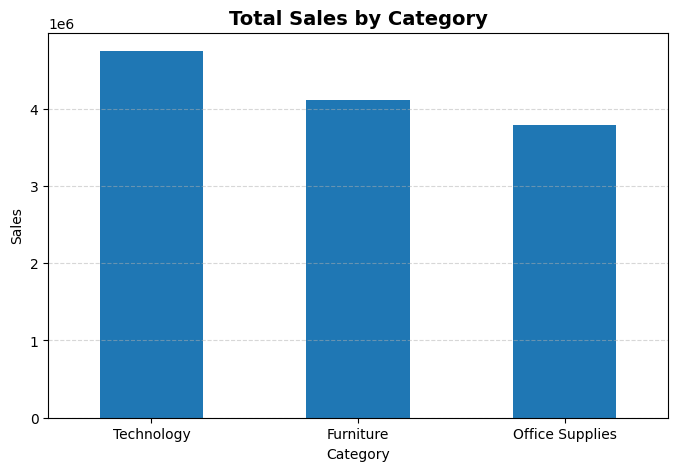

In [23]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Total Sales by Category", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

** Business Insight

- Technology is the highest revenue-generating category with total sales of 4.74 million.
- Furniture ranks second with sales of 4.11 million.
- Office Supplies generated the lowest sales among the three categories.
- The company should continue investing in the Technology category while analyzing opportunities to improve sales in Office Supplies.**

**Profit Analysis

This section analyzes profit generated by each product category to identify the most profitable business segment.**

In [24]:
category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False)

category_profit

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64

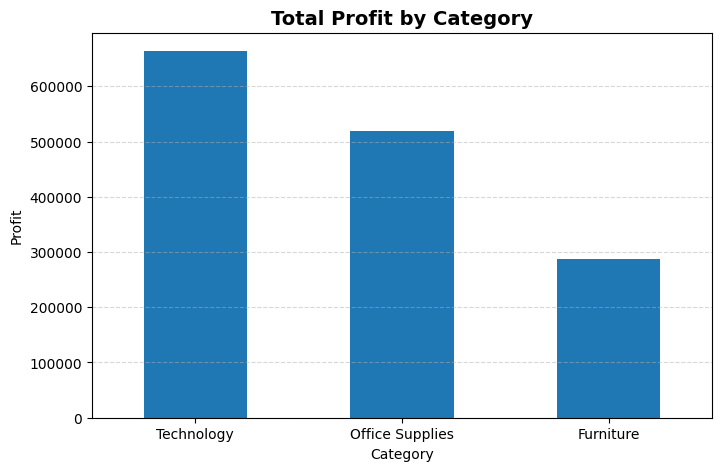

In [25]:
plt.figure(figsize=(8,5))

category_profit.plot(kind='bar')

plt.title("Total Profit by Category", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

**Business Insight

- Technology is the most profitable category and also generates the highest sales.
- Although Furniture has higher sales than Office Supplies, it generates lower profit.
- This indicates that Furniture products may have lower profit margins, higher discounts, or higher operational costs.
- The company should investigate the Furniture category to improve profitability.**

# Sales by Sub-Category

This analysis identifies the top-performing product sub-categories based on total sales.

In [26]:
subcategory_sales = (
    df.groupby('sub_category')['sales']
      .sum()
      .sort_values(ascending=False)
)

subcategory_sales.head(10)

sub_category
Phones         1706874
Copiers        1509439
Chairs         1501682
Bookcases      1466559
Storage        1127124
Appliances     1011081
Machines        779071
Tables          757034
Accessories     749307
Binders         461952
Name: sales, dtype: int64

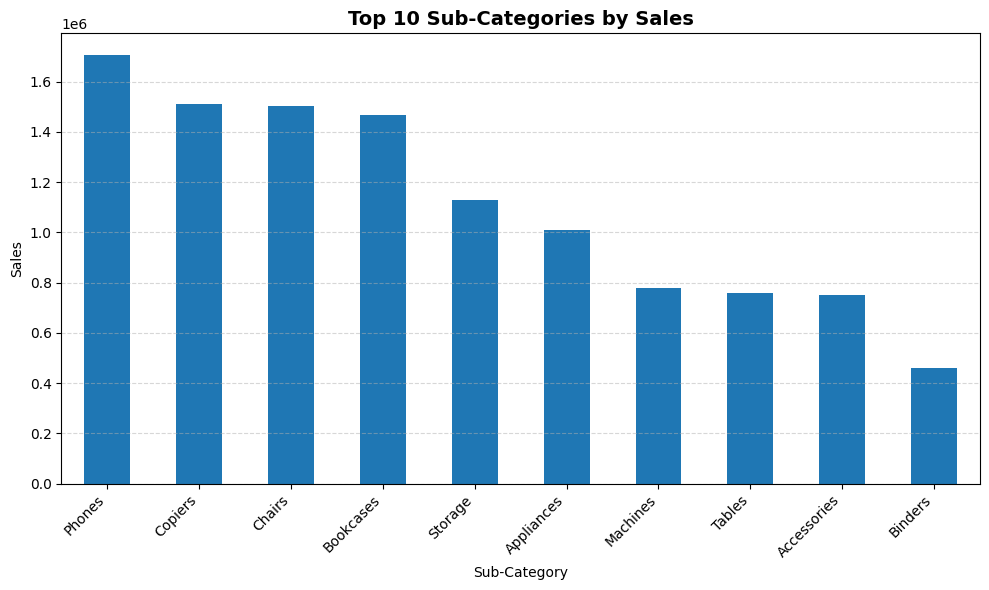

In [27]:
plt.figure(figsize=(10,6))

subcategory_sales.head(10).plot(kind='bar')

plt.title("Top 10 Sub-Categories by Sales", fontsize=14, fontweight='bold')
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Top Customers Analysis

This analysis identifies the top 10 customers who generated the highest sales for the business.

In [28]:
top_customers = (
    df.groupby('customer_name')['sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

customer_name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Bart Watters          32315
Natalie Fritzler      31778
Fred Hopkins          30404
Jane Waco             30288
Hunter Lopez          30246
Name: sales, dtype: int64

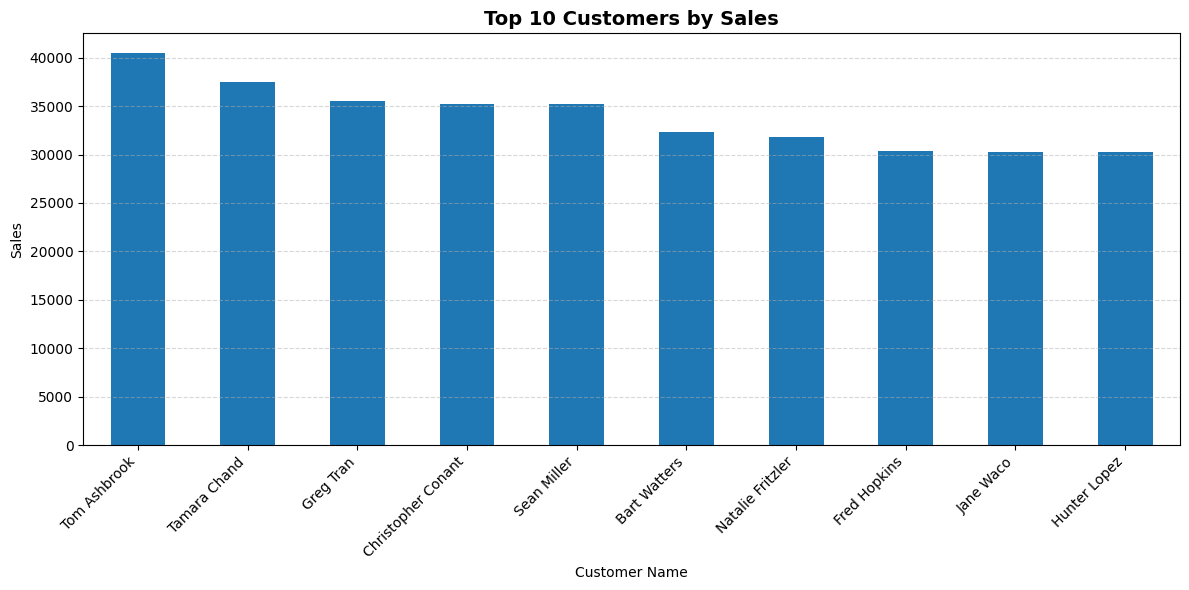

In [29]:
plt.figure(figsize=(12,6))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Sales", fontsize=14, fontweight='bold')
plt.xlabel("Customer Name")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("../Images/top_10_customers_sales.png", dpi=300, bbox_inches="tight")

plt.show()

# Top Products Analysis

This analysis identifies the top-selling products based on total sales.

In [30]:
top_products = (
    df.groupby('product_name')['sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

product_name
Apple Smart Phone, Full Size                                86936
Cisco Smart Phone, Full Size                                76441
Motorola Smart Phone, Full Size                             73159
Nokia Smart Phone, Full Size                                71904
Canon imageCLASS 2200 Advanced Copier                       61600
Hon Executive Leather Armchair, Adjustable                  58200
Office Star Executive Leather Armchair, Adjustable          50667
Harbour Creations Executive Leather Armchair, Adjustable    50120
Samsung Smart Phone, Cordless                               48654
Nokia Smart Phone, with Caller ID                           47880
Name: sales, dtype: int64

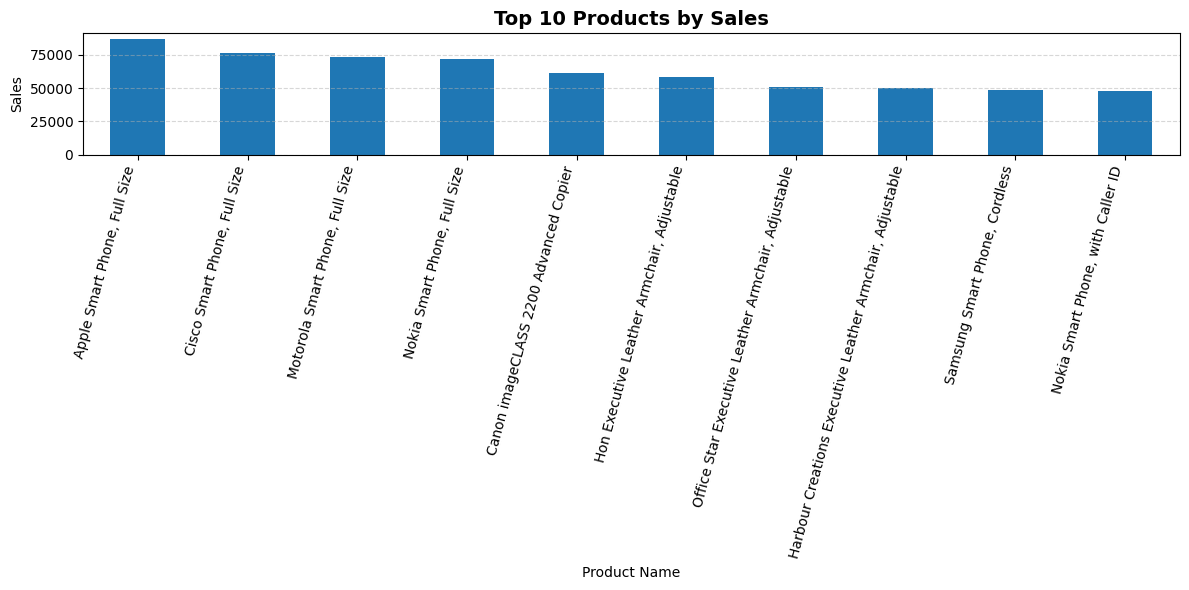

In [31]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales", fontsize=14, fontweight='bold')
plt.xlabel("Product Name")
plt.ylabel("Sales")

plt.xticks(rotation=75, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("../Images/top_10_products_sales.png", dpi=300, bbox_inches="tight")

plt.show()

**Sales by Region**

In [32]:
region_sales = (
    df.groupby('region')['sales']
      .sum()
      .sort_values(ascending=False)
)

region_sales

region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
EMEA               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: sales, dtype: int64

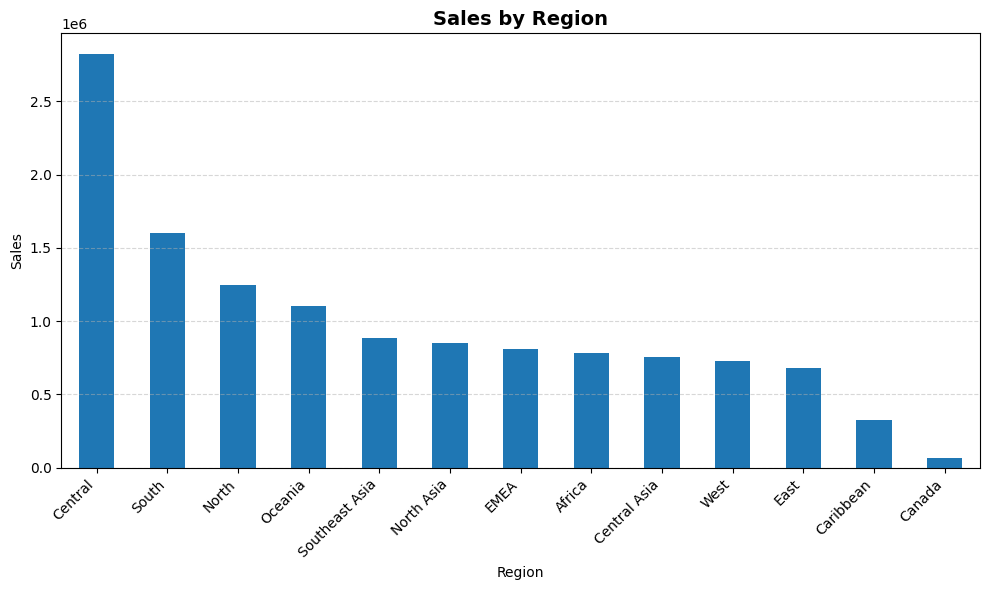

In [33]:
plt.figure(figsize=(10,6))

region_sales.plot(kind='bar')

plt.title("Sales by Region", fontsize=14, fontweight='bold')
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("../Images/sales_by_region.png", dpi=300, bbox_inches="tight")

plt.show()

# Sales by Market

This analysis identifies which market contributes the highest sales.

In [34]:
market_sales = (
    df.groupby('market')['sales']
      .sum()
      .sort_values(ascending=False)
)

market_sales

market
APAC      3585833
EU        2938139
US        2297354
LATAM     2164687
EMEA       806184
Africa     783776
Canada      66932
Name: sales, dtype: int64

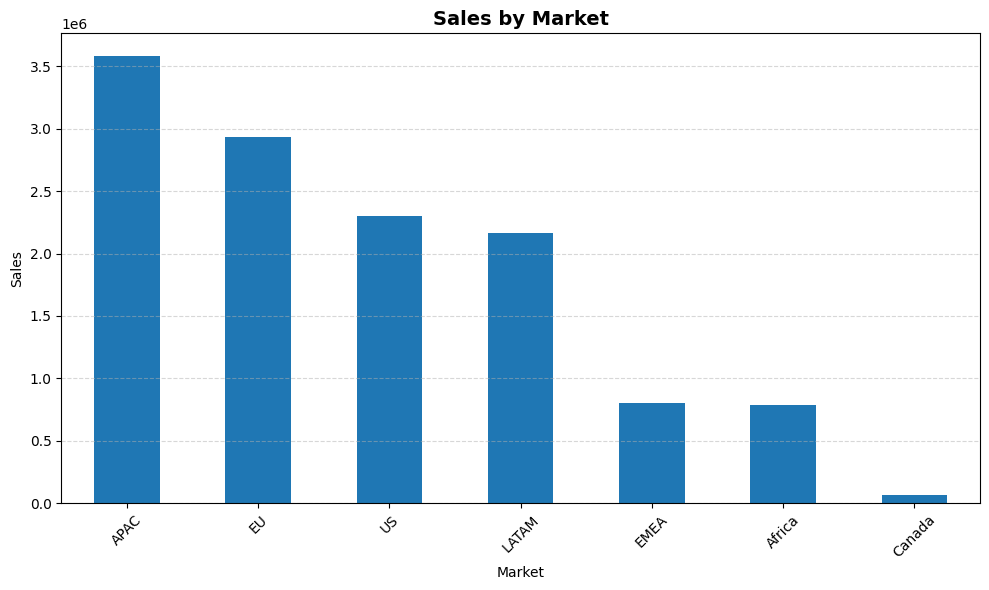

In [35]:
plt.figure(figsize=(10,6))

market_sales.plot(kind='bar')

plt.title("Sales by Market", fontsize=14, fontweight='bold')
plt.xlabel("Market")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("../Images/sales_by_market.png", dpi=300, bbox_inches="tight")

plt.show()

**Monthly Sales Trend**

In [36]:
df['Month'] = df['order_date'].dt.month_name()
df['Month_Number'] = df['order_date'].dt.month
df['Year'] = df['order_date'].dt.year

In [37]:
monthly_sales = (
    df.groupby('Month_Number')['sales']
      .sum()
      .reset_index()
)

monthly_sales

,Month_Number,sales
0,1,675141
1,2,543768
2,3,770519
3,4,698603
4,5,904061
5,6,1269751
6,7,749423
7,8,1293852
8,9,1437432
9,10,1168220


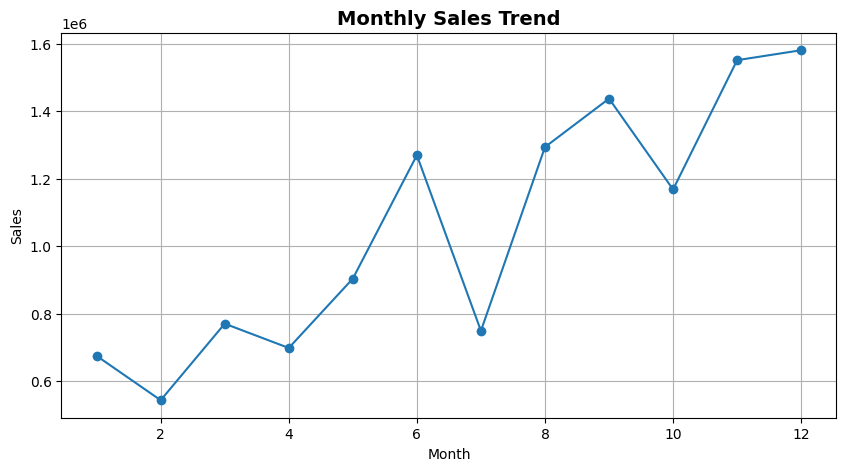

In [38]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales['Month_Number'],
         monthly_sales['sales'],
         marker='o')

plt.title("Monthly Sales Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.savefig("../Images/monthly_sales_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Sales vs Profit Relationship**

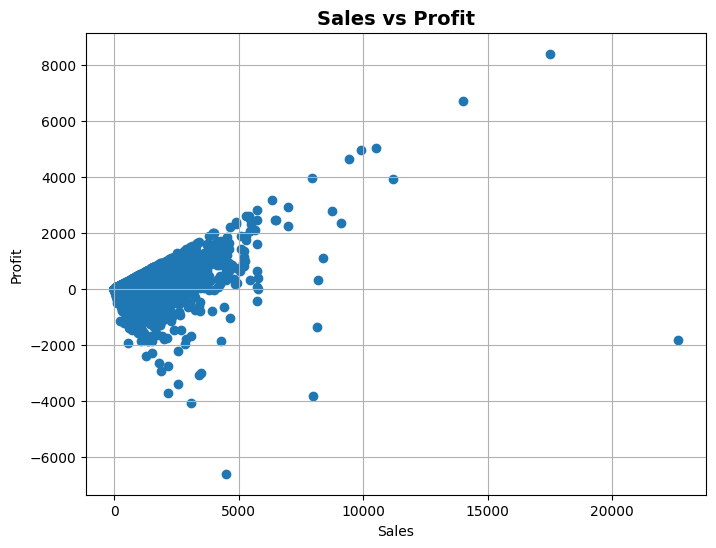

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(df['sales'], df['profit'])

plt.title("Sales vs Profit", fontsize=14, fontweight='bold')
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.grid(True)

plt.savefig("../Images/sales_vs_profit.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [40]:
correlation = df[['sales','profit','quantity','discount','shipping_cost']].corr()

correlation

,sales,profit,quantity,discount,shipping_cost
sales,1.000000,0.485944,0.313580,-0.086728,0.768075
profit,0.485944,1.000000,0.104743,-0.316375,0.357033
quantity,0.313580,0.104743,1.000000,-0.019875,0.272649
discount,-0.086728,-0.316375,-0.019875,1.000000,-0.079056
shipping_cost,0.768075,0.357033,0.272649,-0.079056,1.000000


# Loss Making Products

This analysis identifies the products that generated the highest losses.

In [41]:
loss_products = (
    df.groupby('product_name')['profit']
      .sum()
      .sort_values()
      .head(10)
)

loss_products

product_name
Cubify CubeX 3D Printer Double Head Print                  -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                  -4589.9730
Motorola Smart Phone, Cordless                             -4447.0380
Cubify CubeX 3D Printer Triple Head Print                  -3839.9904
Bevis Round Table, Adjustable Height                       -3649.8940
Bevis Computer Table, Fully Assembled                      -3509.5638
Rogers Lockers, Blue                                       -2893.4908
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Bevis Wood Table, with Bottom Storage                      -2782.5880
Lesro Training Table, Rectangular                          -2581.2834
Name: profit, dtype: float64

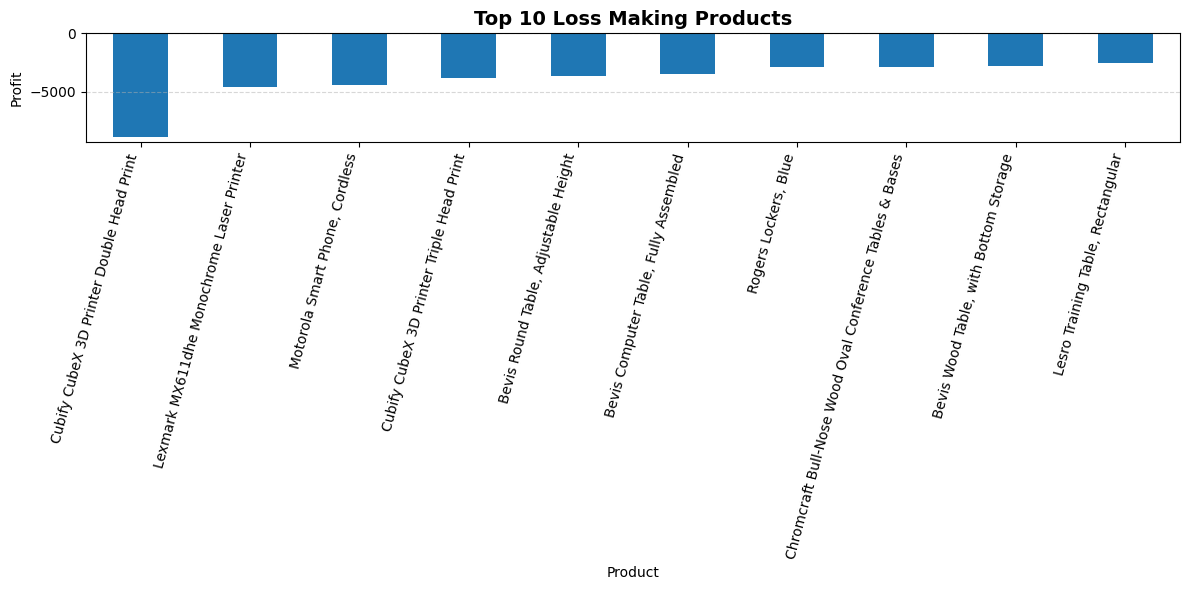

In [42]:
plt.figure(figsize=(12,6))

loss_products.plot(kind='bar')

plt.title("Top 10 Loss Making Products", fontsize=14, fontweight='bold')
plt.xlabel("Product")
plt.ylabel("Profit")

plt.xticks(rotation=75, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("../Images/loss_products.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Shipping Mode Analysis**

In [43]:
shipping_sales = (
    df.groupby('ship_mode')['sales']
      .sum()
      .sort_values(ascending=False)
)

shipping_sales

ship_mode
Standard Class    7578889
Second Class      2565747
First Class       1831067
Same Day           667202
Name: sales, dtype: int64

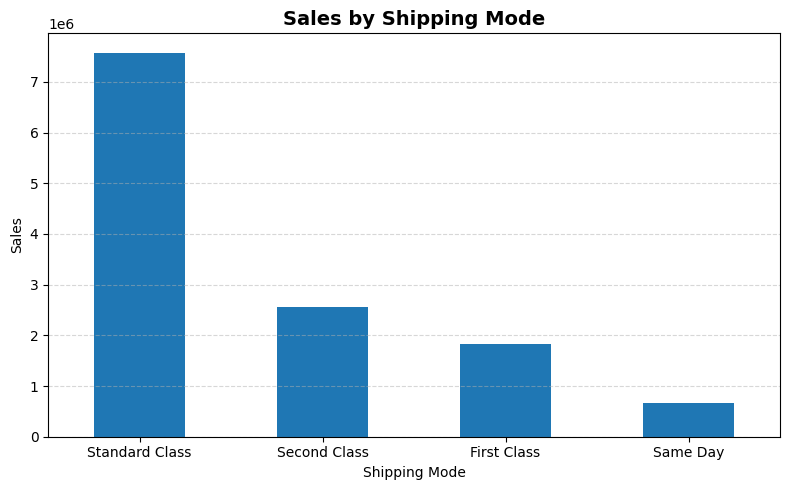

In [44]:
plt.figure(figsize=(8,5))

shipping_sales.plot(kind='bar')

plt.title("Sales by Shipping Mode", fontsize=14, fontweight='bold')
plt.xlabel("Shipping Mode")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("../Images/shipping_mode_sales.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Feature Engineering**

In [45]:
df['delivery_days'] = (df['ship_date'] - df['order_date']).dt.days

In [46]:
df['delivery_days'].describe()

count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: delivery_days, dtype: float64

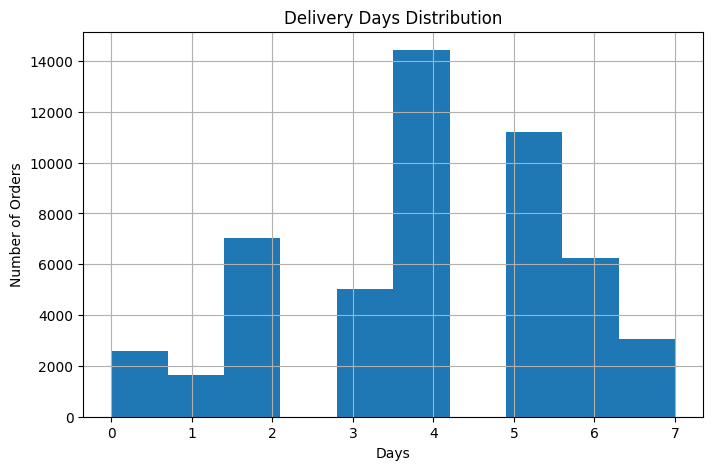

In [47]:
plt.figure(figsize=(8,5))

df['delivery_days'].hist(bins=10)

plt.title("Delivery Days Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Orders")

plt.grid(True)

plt.savefig("../Images/delivery_days_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Profit Margin**

In [48]:
df['profit_margin'] = (df['profit'] / df['sales']) * 100

In [49]:
df['profit_margin'].describe()

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    5.129000e+04
mean             -inf
std               NaN
min              -inf
25%      0.000000e+00
50%      1.692552e+01
75%      3.331303e+01
max      5.828000e+01
Name: profit_margin, dtype: float64

In [50]:
margin = df.groupby('category')['profit_margin'].mean()

margin

category
Furniture          0.874818
Office Supplies        -inf
Technology         4.965838
Name: profit_margin, dtype: float64

**Average Delivery Days by Ship Mode**

# Delivery Performance by Ship Mode

This analysis compares the average delivery time across different shipping modes.

In [51]:
delivery_mode = (
    df.groupby('ship_mode')['delivery_days']
      .mean()
      .sort_values()
)

delivery_mode

ship_mode
Same Day          0.037394
First Class       2.181746
Second Class      3.230187
Standard Class    4.998018
Name: delivery_days, dtype: float64

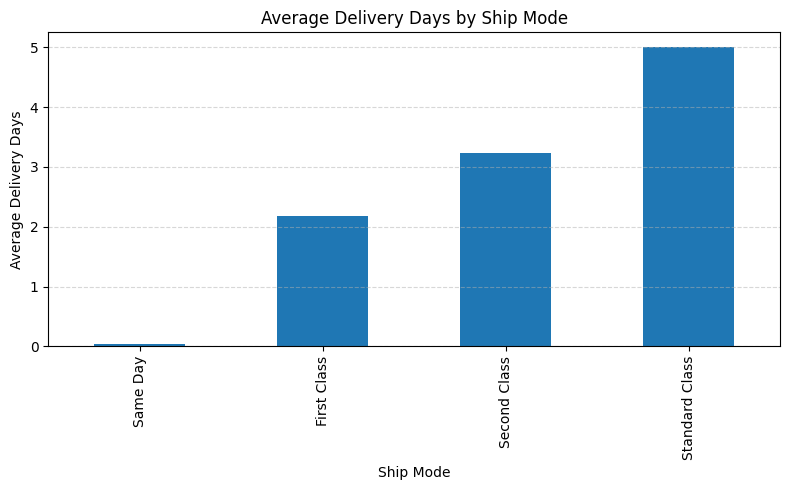

In [52]:
plt.figure(figsize=(8,5))

delivery_mode.plot(kind='bar')

plt.title("Average Delivery Days by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Delivery Days")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("../Images/delivery_days_shipmode.png", dpi=300)

plt.show()

**Profit Margin by Market**

In [53]:
market_margin = (
    df.groupby('market')['profit_margin']
      .mean()
      .sort_values(ascending=False)
)

market_margin

market
Canada    24.743089
EU        11.016694
APAC       6.958356
LATAM      6.171163
EMEA     -14.161834
Africa   -14.509152
US             -inf
Name: profit_margin, dtype: float64

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


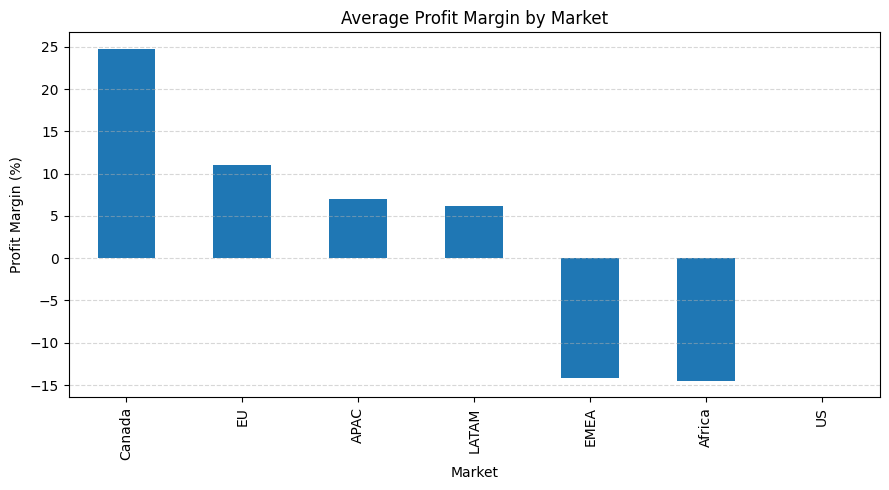

In [54]:
plt.figure(figsize=(9,5))

market_margin.plot(kind='bar')

plt.title("Average Profit Margin by Market")
plt.xlabel("Market")
plt.ylabel("Profit Margin (%)")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("../Images/profit_margin_market.png", dpi=300)

plt.show()

**Delivery Days vs Profit**

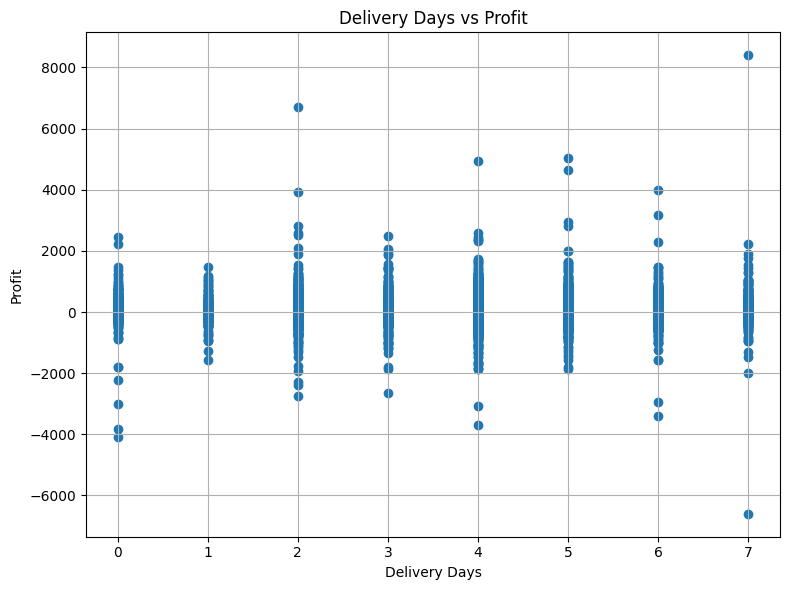

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(df['delivery_days'], df['profit'])

plt.title("Delivery Days vs Profit")
plt.xlabel("Delivery Days")
plt.ylabel("Profit")

plt.grid(True)

plt.tight_layout()

plt.savefig("../Images/delivery_days_vs_profit.png", dpi=300)

plt.show()

# Executive Summary

## Project Overview

This project analyzes a global Superstore sales dataset to understand business performance, customer behavior, product performance, profitability, and logistics efficiency.

## Key Findings

- Total Sales: 12.64 Million
- Total Profit: 1.47 Million
- Technology generated the highest sales and profit.
- Furniture generated high sales but relatively lower profit.
- November and December recorded the highest sales.
- Discounts negatively impacted profitability.
- Shipping Cost showed a strong positive correlation with Sales.
- A small number of customers contributed a significant portion of revenue.
- Delivery performance was consistent across different shipping modes.

The analysis provides valuable business insights for improving profitability and decision-making.

# Business Recommendations

1. Increase investment in Technology products as they generate the highest sales and profit.

2. Review the pricing and discount strategy for Furniture products to improve profit margins.

3. Reduce excessive discounts on low-margin products.

4. Focus marketing campaigns during November and December to maximize seasonal sales.

5. Strengthen customer loyalty programs for top-performing customers.

6. Monitor loss-making products and revise pricing strategies.

7. Improve business performance in low-performing regions and markets.

8. Optimize shipping operations to reduce logistics costs while maintaining delivery efficiency.